In [44]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Create the dataframe of the three specific gates**

In [46]:
or_data = pd.DataFrame()
and_data = pd.DataFrame()
xor_data = pd.DataFrame()

In [47]:
or_data

""


In [48]:
or_data['input1'] = [1, 1, 0, 0]
or_data['input2'] = [1, 0, 1, 0]
or_data['output'] = [1, 1, 1, 0]
or_data

,input1,input2,output
0,1,1,1
1,1,0,1
2,0,1,1
3,0,0,0


In [49]:
and_data['input1'] = [1, 1, 0, 0]
and_data['input2'] = [1, 0, 1, 0]
and_data['output'] = [1, 0, 0, 0]
print(and_data)

   input1  input2  output
0       1       1       1
1       1       0       0
2       0       1       0
3       0       0       0


In [50]:
xor_data['input1'] = [1, 1, 0, 0]
xor_data['input2'] = [1, 0, 1, 0]
xor_data['output'] = [0, 1, 1, 0]
print(xor_data)

   input1  input2  output
0       1       1       0
1       1       0       1
2       0       1       1
3       0       0       0


**Create the visualizations of all the above mentioned gates**

<Axes: xlabel='input1', ylabel='input2'>

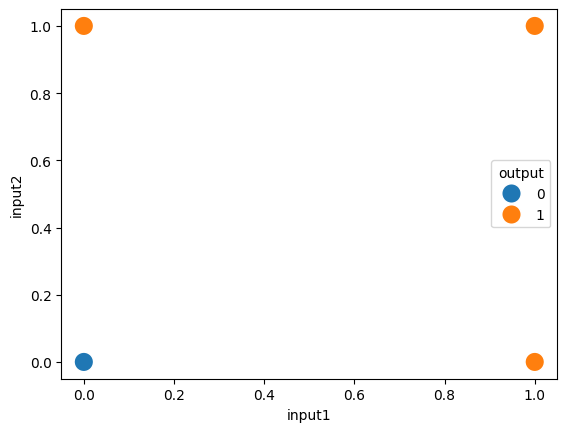

In [51]:
sns.scatterplot(x=or_data['input1'], y=or_data['input2'], hue=or_data['output'], s=200)

<Axes: xlabel='input1', ylabel='input2'>

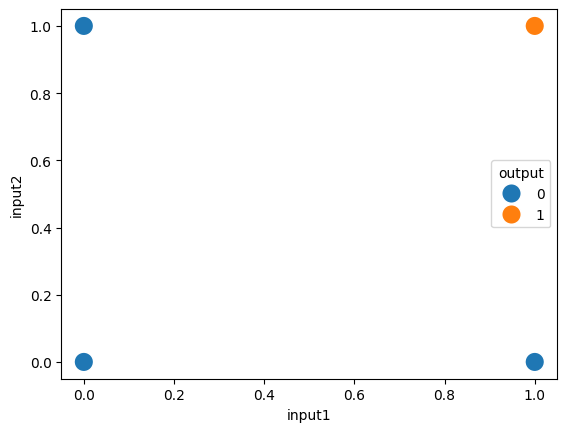

In [52]:
sns.scatterplot(x=and_data['input1'], y=and_data['input2'], hue=and_data['output'], s=200)

<Axes: xlabel='input1', ylabel='input2'>

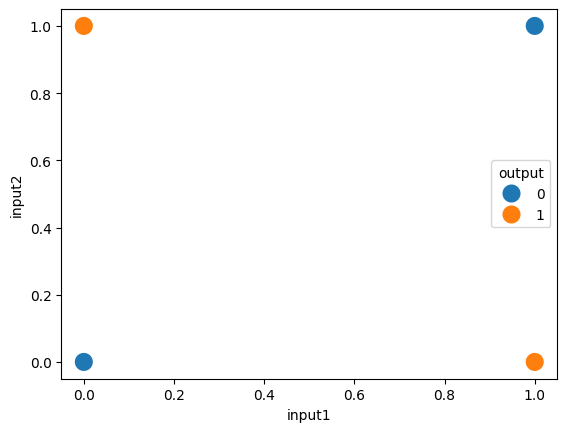

In [53]:
sns.scatterplot(x=xor_data['input1'], y=xor_data['input2'], hue=xor_data['output'], s=200)

**Create a perceptron classifier using sklearn**

In [ ]:
# The Perceptron is the simplest neural network — it is a single neuron model used for binary classification.

In [54]:
from sklearn.linear_model import Perceptron
classifier_or = Perceptron()
classifier_and = Perceptron()
classifier_xor = Perceptron()

In [55]:
classifier_or.fit(or_data.iloc[:,0:2].values,or_data.iloc[:,-1].values)
classifier_and.fit(and_data.iloc[:,0:2].values,and_data.iloc[:,-1].values)
classifier_xor.fit(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [ ]:
classifier_or.coef_   # this refers to slope

array([[2., 2.]])

In [59]:
classifier_or.score

<bound method ClassifierMixin.score of Perceptron()>

In [ ]:
classifier_or.intercept_  # this refers to the bias / intercept in line equation y=wa+b

array([-1.])

**Limitation Of Perceptron: It is easily able to create the linear decision boundaries but for non-linear functions, it won't be able to create the decision boundaries.**

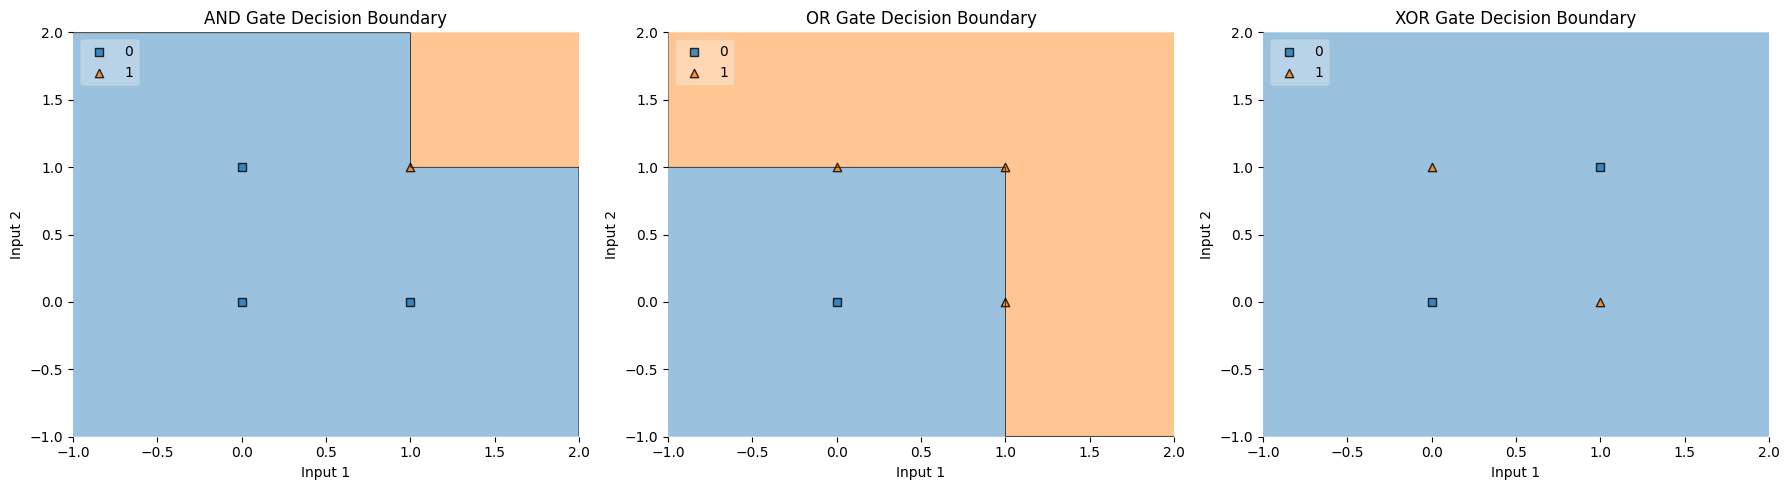

In [61]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

# ---------------- AND ----------------
plt.subplot(1,3,1)
plt.title('AND Gate Decision Boundary')

plot_decision_regions(
    X=and_data.iloc[:,0:2].values,
    y=and_data.iloc[:,-1].values,
    clf=classifier_and,
    legend=2
)

plt.xlabel('Input 1')
plt.ylabel('Input 2')


# ---------------- OR ----------------
plt.subplot(1,3,2)
plt.title('OR Gate Decision Boundary')

plot_decision_regions(
    X=or_data.iloc[:,0:2].values,
    y=or_data.iloc[:,-1].values,
    clf=classifier_or,
    legend=2
)

plt.xlabel('Input 1')
plt.ylabel('Input 2')


# ---------------- XOR ----------------
plt.subplot(1,3,3)
plt.title('XOR Gate Decision Boundary')

plot_decision_regions(
    X=xor_data.iloc[:,0:2].values,
    y=xor_data.iloc[:,-1].values,
    clf=classifier_xor,
    legend=2
)

plt.xlabel('Input 1')
plt.ylabel('Input 2')


plt.tight_layout()
plt.show()

In [65]:
# Failed to plt for XOR 
xor_data

,input1,input2,output
0,1,1,0
1,1,0,1
2,0,1,1
3,0,0,0


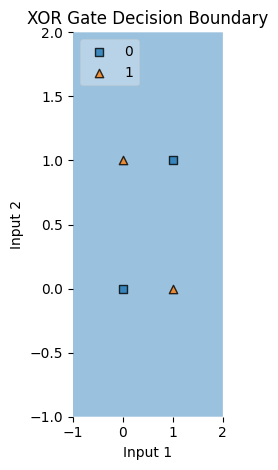

In [63]:
plt.subplot(1,3,3)
plt.title('XOR Gate Decision Boundary')

plot_decision_regions(
    X=xor_data.iloc[:,0:2].values,
    y=xor_data.iloc[:,-1].values,
    clf=classifier_xor,
    legend=2
)

plt.xlabel('Input 1')
plt.ylabel('Input 2')


plt.tight_layout()
plt.show()

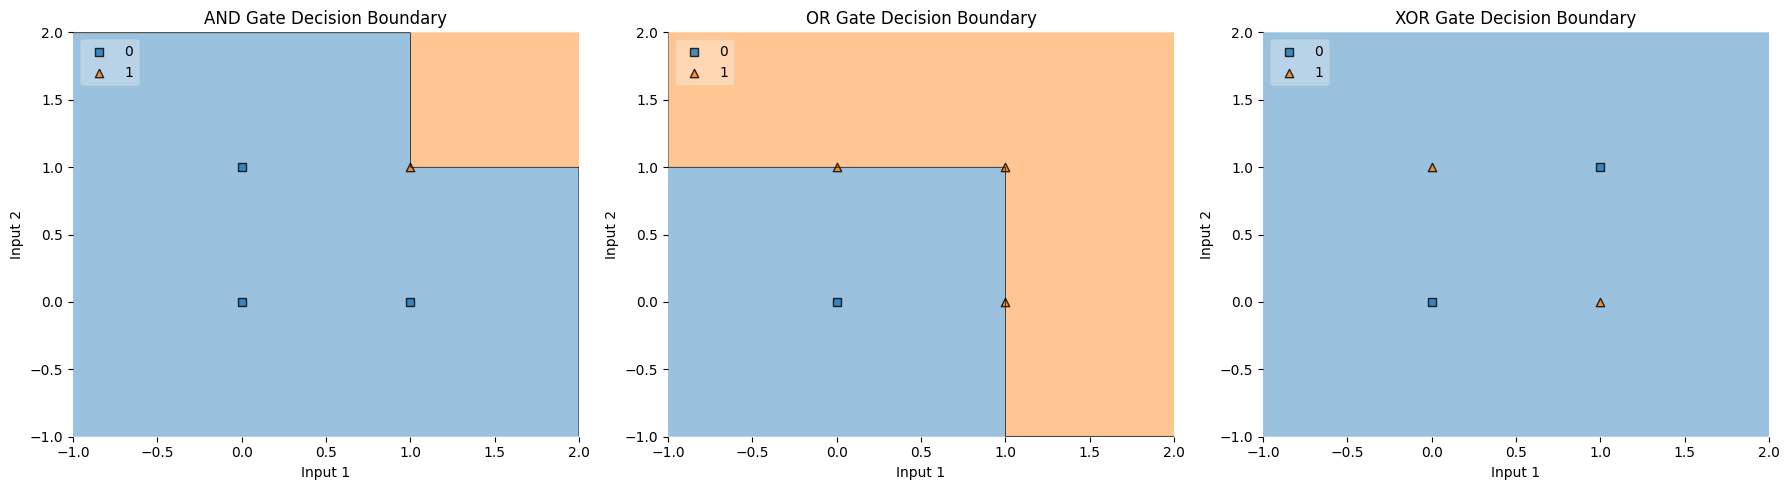

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AND Classifier Decision Boundary
axes[0].set_title('AND Gate Decision Boundary')
plot_decision_regions(X=and_data.iloc[:,0:2].values, y=and_data.iloc[:,-1].values, clf=classifier_and, legend=2, ax=axes[0])
axes[0].set_xlabel('Input 1')
axes[0].set_ylabel('Input 2')

# OR Classifier Decision Boundary
axes[1].set_title('OR Gate Decision Boundary')
plot_decision_regions(X=or_data.iloc[:,0:2].values, y=or_data.iloc[:,-1].values, clf=classifier_or, legend=2, ax=axes[1])
axes[1].set_xlabel('Input 1')
axes[1].set_ylabel('Input 2')

# XOR Classifier Decision Boundary
axes[2].set_title('XOR Gate Decision Boundary')
plot_decision_regions(X=xor_data.iloc[:,0:2].values, y=xor_data.iloc[:,-1].values, clf=classifier_xor, legend=2, ax=axes[2])
axes[2].set_xlabel('Input 1')
axes[2].set_ylabel('Input 2')

plt.tight_layout()
plt.show()